# Lab 4: Why Classical Machine Learning

## Objectives

1. To understand Jaccard Similarity and its limitations.
2. To understand Cosine Similarity for measuring document similarity.
3. To study TF-IDF and how it assigns importance to words.
4. To understand the working principle of K-Nearest Neighbor (KNN).

---

# 1. Jaccard Similarity

Jaccard Similarity measures the similarity between two documents by comparing the overlap between their word sets. It measures how much two sets share common elements.

It is commonly used in **Natural Language Processing (NLP), Machine Learning, and Recommendation Systems** for measuring similarity between datasets.

## Formula

JS = |Intersection (∩)| / |Union (∪)|

## Example

**Paper 1:** "vision AI vision"

Set representation:

```
{vision, AI}
```

Size = 2


**Paper 2:** "NLP AI"

Set representation:

```
{NLP, AI}
```

Size = 2


### Intersection

\[
\{AI\}=1
\]


### Union

\[
\{vision, AI, NLP\}=3
\]


Therefore,

\[
JS(paper1,paper2)=1/3=0.33
\]


The similarity between the two documents is **33%**.

---

## Limitations of Jaccard Similarity

- Jaccard only checks unique words.
- It does not consider the frequency of words.
- A word appearing once or ten times is treated equally.
- It cannot identify the importance of words in a document.

---

# 2. Cosine Similarity

Cosine Similarity represents documents as vectors and measures the angle between those vectors.

A smaller angle between vectors represents higher similarity.

## Formula

CS = (A · B) / (|A| × |B|)

Where:

- **A.B** = Dot product between two vectors
- **|A| and |B|** = Magnitude of vectors


## Example

Documents:

**Document 1:** "NLP AI vision"

**Document 2:** "NLP AI"


Vocabulary:

| Document | Vision | AI | NLP |
|----------|--------|----|-----|
| Document 1 | 2 | 1 | 0 |
| Document 2 | 0 | 1 | 1 |


### Dot Product

A · B = (2×0) + (1×1) + (0×1)  =  0 + 1 + 0  =  1

\[
A.B=1
\]


### Magnitude of A

|A| = √(2² + 1² + 0²) = √(4+1+0) = √5 ≈ 2.236



### Magnitude of B

|B| = √(0² + 1² + 1²) = √(0+1+1) = √2 ≈ 1.414


### Result

CS = 1 / (2.236 × 1.414) = 1 / 3.162 ≈ 0.316  →  31.6% similar

Similarity = **31.6%**

---

# 3. TF-IDF (Term Frequency - Inverse Document Frequency)

Basic Jaccard Similarity and Cosine Similarity treat all words equally.

TF-IDF improves this by assigning statistical weights to words based on their importance.


Common words like:

- the
- a
- is

appear in many documents, so they provide less information.


TF-IDF provides:

- Lower weight to common words.
- Higher weight to rare and meaningful words.


## IDF Formula

TF-IDF = TF × IDF
IDF = log(Total Documents / Documents containing the term)

Where:

- **N** = Total number of documents
- **DF** = Number of documents containing the term


## Example

| Term | IDF Calculation | IDF Value |
|------|----------------|-----------|
| Transformer | log(3/3) | 0 |
| NLP | log(3/1) | 1.0 |
| CV | log(3/1) | 0.48 |


## Explanation

### Transformer

"Transformer" appears in all 3 documents:

\[
IDF=log(3/3)=0
\]

It receives **no weight** because it does not help identify a specific document.


### NLP

"NLP" appears in only one document:

\[
IDF=log(3/1)
\]

It receives higher weight because it is unique and informative.

---

# 4. K-Nearest Neighbor (KNN)

K-Nearest Neighbor (KNN) is a simple supervised machine learning algorithm used for classification and regression tasks.


It works by identifying the **K closest data points** to a given input and making predictions based on those neighboring points.


## Working Principle of KNN

1. Select the value of K.
2. Calculate the distance between the new data point and existing data points.
3. Select the K nearest neighbors.
4. For classification, choose the majority class.
5. For regression, calculate the average value of neighbors.


## Why KNN?

- Simple and easy to understand.
- Does not require a separate training phase.
- Works well with small datasets.
- Useful for similarity-based prediction.


## Limitations of KNN

- Slow for large datasets.
- Requires storing all training data.
- Performance depends on the choice of K.
- Sensitive to irrelevant features and feature scaling.

### CODE FOR JACCARD SIMILARITY

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors


paper_titles = [
    # Computer Vision Papers (1-10)
    ("ResNet-3D: Residual Grids for Spatial Volumetric Analysis", "CV", "CNNs", "Dr_Y_LeCun"),
    ("ViT-Scale: Scaling Vision Transformers for Dense Prediction", "CV", "Transformers", "Dr_A_Vaswani"),
    ("SimCLR-V3: Contrastive Frameworks for Self-Supervised Vision", "CV", "CL", "Dr_G_Hinton"),
    ("Masked Autoencoders Are Scalable Vision Visualizers", "CV", "Transformers", "Dr_Y_LeCun"),
    ("NeRF-Graph: Neural Radiance Fields on Graph Topologies", "CV", "GNNs", "Dr_J_Leskovec"),
    ("Real-Time Semantic Segmentation via Dilated Spatial Kernels", "CV", "CNNs", "Dr_Y_LeCun"),
    ("Cross-Modal Vector Alignment in Generative Vision Spaces", "CV", "CL", "Dr_G_Hinton"),
    ("Attention-Driven Object Detection in High-Resolution Imagery", "CV", "Transformers", "Dr_A_Vaswani"),
    ("Unsupervised Visual Representation via Contrastive Residuals", "CV", "CL", "Dr_G_Hinton"),
    ("Geometry-Aware Convolutions for 3D Point Cloud Processing", "CV", "CNNs", "Dr_J_Leskovec"),

    # NLP Papers (11-20)
    ("BERT-Large: Pre-training of Deep Bidirectional Transformers", "NLP", "Transformers", "Dr_A_Vaswani"),
    ("GPT-Next: Autoregressive Language Modeling at Scale", "NLP", "Transformers", "Dr_A_Vaswani"),
    ("Contrastive Sentence Embeddings via Semantic Invariance", "NLP", "CL", "Dr_Y_Bengio"),
    ("Long-Short Sequence Parsing via Linear Attention Windows", "NLP", "Transformers", "Dr_A_Vaswani"),
    ("Text-Graph Recurrent Transformers for Structured Document Analysis", "NLP", "GNNs", "Dr_J_Leskovec"),
    ("Exploring the Limits of Self-Supervised Machine Translation", "NLP", "CL", "Dr_Y_Bengio"),
    ("Dependency-Parsing Convolutions for Low-Resource Languages", "NLP", "CNNs", "Dr_Y_LeCun"),
    ("Token-Free Language Representations via Character-Level Processing", "NLP", "Transformers", "Dr_Y_Bengio"),
    ("Retrieval-Augmented Transformers for Dynamic Knowledge Graphs", "NLP", "Transformers", "Dr_J_Leskovec"),
    ("Evaluating Prompt Calibration Metrics in LLM Quantization", "NLP", "Transformers", "Dr_Y_Bengio"),

    # Graph AI Papers (21-30)
    ("GCN-V2: Scalable Graph Convolutional Networks via Node Sampling", "Graph_AI", "GNNs", "Dr_J_Leskovec"),
    ("Graph Attention Networks with Multi-Head Structural Alignment", "Graph_AI", "Transformers", "Dr_A_Vaswani"),
    ("Self-Supervised Graph Contrastive Learning via Subgraph Masking", "Graph_AI", "CL", "Dr_Y_Bengio"),
    ("Message-Passing Frameworks for Heterogeneous Molecular Topologies", "Graph_AI", "GNNs", "Dr_G_Hinton"),
    ("Graph Convolutions Meet Vision Transformers: A Unified Review", "Graph_AI", "Transformers", "Dr_Y_LeCun"),
    ("Temporal Graph Networks for Dynamic Relational Interaction Stream", "Graph_AI", "GNNs", "Dr_J_Leskovec"),
    ("Inductive Representation Learning on Large-Scale Social Webs", "Graph_AI", "GNNs", "Dr_J_Leskovec"),
    ("Contrastive Node Clustering via Graph Diffusion Wavelets", "Graph_AI", "CL", "Dr_G_Hinton"),
    ("Deep Generative Models for Graph Structure Deconvolution", "Graph_AI", "CNNs", "Dr_Y_LeCun"),
    ("Scalable Graph Neural Architecture Search via Gradient Descent", "Graph_AI", "GNNs", "Dr_Y_Bengio")
]

# Convert the raw nested sequence into a structured Pandas DataFrame
columns = ["Title", "Domain_Code", "Methodology_Code", "Primary_Author"]
df = pd.DataFrame(paper_titles, columns=columns)
df.insert(0, 'Paper_ID', range(1, len(df) + 1))

# Optionally save to disk to inspect structural data
df.to_csv('research_papers_network.csv', index=False)


# Combine descriptive features and text metadata fields into a singular text profile string
df['Features_Corpus'] = df['Title'] + " " + df['Domain_Code'] + " " + df['Methodology_Code'] + " " + df['Primary_Author']

# Lowercase everything to ensure string consistency and eliminate casing bias
df['Features_Corpus'] = df['Features_Corpus'].str.lower()


vectorizer = TfidfVectorizer(stop_words='english', token_pattern=r'(?u)\b\w+\b')

tfidf_matrix = vectorizer.fit_transform(df['Features_Corpus'])


knn_model = NearestNeighbors(n_neighbors=6, metric='cosine', algorithm='brute')
knn_model.fit(tfidf_matrix)

target_title = "Unsupervised Visual Representation via Contrastive Residuals"
query_idx = df[df['Title'] == target_title].index[0]

# Query the KNN tree to get spatial coordinate arrays for closest nodes
distances, indices = knn_model.kneighbors(tfidf_matrix[query_idx])

# Display machine learning recommendations
print(f"Target Input Paper: '{df.iloc[query_idx]['Title']}'")
print("=" * 95)

# Loop starting from index 1 (skipping 0 because index 0 is always the target paper itself)
for rank in range(1, len(distances[0])):
    match_idx = indices[0][rank]
    cosine_distance = distances[0][rank]

    # Mathematical transformation: Similarity = 1 - Distance
    similarity_score = 1 - cosine_distance

    print("Recommendation #{rank:02d}: {df.iloc[match_idx]['Title']:<70} [Score: {similarity_score:.4f}]")


Target Input Paper: 'Unsupervised Visual Representation via Contrastive Residuals'
Recommendation #{rank:02d}: {df.iloc[match_idx]['Title']:<70} [Score: {similarity_score:.4f}]
Recommendation #{rank:02d}: {df.iloc[match_idx]['Title']:<70} [Score: {similarity_score:.4f}]
Recommendation #{rank:02d}: {df.iloc[match_idx]['Title']:<70} [Score: {similarity_score:.4f}]
Recommendation #{rank:02d}: {df.iloc[match_idx]['Title']:<70} [Score: {similarity_score:.4f}]
Recommendation #{rank:02d}: {df.iloc[match_idx]['Title']:<70} [Score: {similarity_score:.4f}]


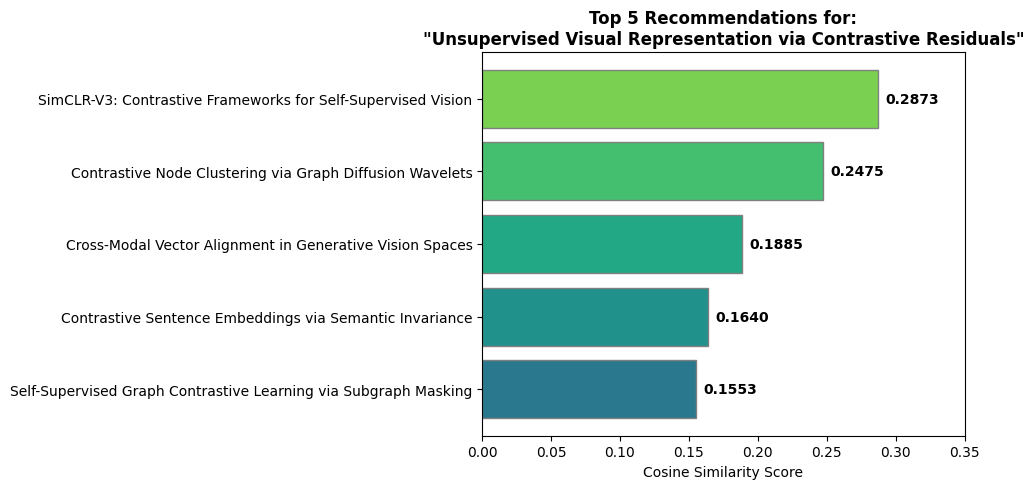

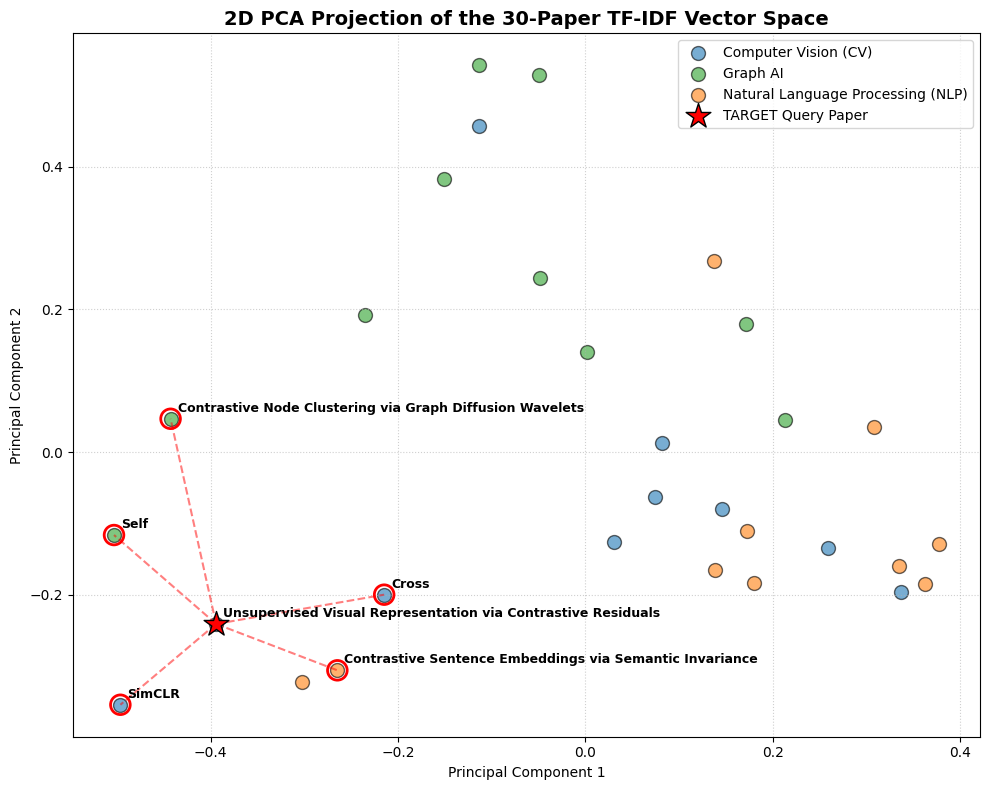

Visualizations successfully compiled and saved to disk.


In [2]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ==============================================================================
# VISUALIZATION MODULE 1: HORIZONTAL BAR CHART OF TOP SIMILARITIES
# ==============================================================================
rec_titles = []
rec_scores = []
for rank in range(1, len(distances[0])):
    match_idx = indices[0][rank]
    sim_score = 1 - distances[0][rank]
    rec_titles.append(df.iloc[match_idx]['Title'])
    rec_scores.append(sim_score)

# Sort recommendations to guarantee sorted descending presentation
rec_data = sorted(zip(rec_titles, rec_scores), key=lambda x: x[1])
sorted_titles, sorted_scores = zip(*rec_data)

# Create Plot canvas using standard subplots to avoid truncation
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.viridis(np.linspace(0.4, 0.8, len(sorted_scores)))
bars = ax.barh(sorted_titles, sorted_scores, color=colors, edgecolor='grey')

ax.set_xlabel('Cosine Similarity Score')
ax.set_title(f'Top 5 Recommendations for:\n"{target_title}"', fontsize=12, fontweight='bold')
ax.set_xlim(0, 0.35)

# Append raw score values cleanly onto the tips of the bars
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.005, bar.get_y() + bar.get_height()/2, f'{width:.4f}',
            va='center', ha='left', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()
plt.close()


# ==============================================================================
# VISUALIZATION MODULE 2: 2D GEOMETRIC PCA PROJECTION
# ==============================================================================
# Compress sparse matrix coordinates to a 2D dense layout plane
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(tfidf_matrix.toarray())
df['X'], df['Y'] = coords[:, 0], coords[:, 1]

fig, ax = plt.subplots(figsize=(10, 8))

# Distribute colors cleanly mapping across academic domain codes
domain_colors = {'CV': '#1f77b4', 'NLP': '#ff7f0e', 'Graph_AI': '#2ca02c'}
domain_labels = {'CV': 'Computer Vision (CV)', 'NLP': 'Natural Language Processing (NLP)', 'Graph_AI': 'Graph AI'}

for domain, group in df.groupby('Domain_Code'):
    ax.scatter(group['X'], group['Y'], label=domain_labels[domain],
               color=domain_colors[domain], s=100, alpha=0.6, edgecolors='black')

# Anchor and highlight target paper index
target_x, target_y = df.iloc[query_idx]['X'], df.iloc[query_idx]['Y']
ax.scatter(target_x, target_y, color='red', marker='*', s=350,
           label='TARGET Query Paper', edgecolors='black', zorder=5)

# Draw spatial connection lines to matching neighbors
neighbor_indices = indices[0][1:]
for idx in neighbor_indices:
    nx, ny = df.iloc[idx]['X'], df.iloc[idx]['Y']
    ax.scatter(nx, ny, facecolors='none', edgecolors='red', s=200, linewidths=2, zorder=4)
    ax.plot([target_x, nx], [target_y, ny], color='red', linestyle='--', alpha=0.5, zorder=3)

# Overlay short acronym annotations onto the vector nodes
for i, row in df.iterrows():
    if i == query_idx or i in neighbor_indices:
        short_name = row['Title'].split(':')[0].split('-')[0]
        ax.annotate(short_name, (row['X'], row['Y']), textcoords="offset points",
                    xytext=(5,5), ha='left', fontsize=9, weight='bold')

ax.set_title('2D PCA Projection of the 30-Paper TF-IDF Vector Space', fontsize=14, fontweight='bold')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.legend(loc='best')
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
# plt.savefig('vector_space_projection.png', dpi=300)
plt.show()
plt.close()

print("Visualizations successfully compiled and saved to disk.")

## Discussion

In this lab, different classical NLP techniques for measuring text similarity were studied. Jaccard Similarity compares documents based on common unique words but ignores word frequency. Cosine Similarity represents documents as vectors and measures their similarity based on vector angles. TF-IDF improves the process by assigning importance to words based on their occurrence. However, these classical methods cannot understand the context and meaning of words, which creates limitations in NLP tasks.

## Conclusion

This lab helped to understand the working and limitations of classical machine learning approaches in NLP. Jaccard Similarity, Cosine Similarity, and TF-IDF are useful for basic text comparison but cannot capture semantic meaning and context. Transformers overcome these limitations by using attention mechanisms to understand relationships between words and provide better language understanding.